In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Stuart-Landau Oscillator

The **Stuart-Landau oscillator** is the normal form of a system near a Hopf bifurcation, expressed in Cartesian coordinates as

$$\dot x = (a - x^2 - y^2)\,x - \omega\,y,\qquad \dot y = (a - x^2 - y^2)\,y + \omega\,x.$$

It is mathematically identical to the Hopf normal form: the parameter $a$ sets the amplitude of the limit cycle ($\sqrt{a}$) and $\omega$ sets the angular frequency. Networks of Stuart-Landau oscillators are widely used to model metastable synchronization in resting-state brain activity.

**Reference:** Kuramoto (1984), *Chemical Oscillations, Waves, and Turbulence*, Springer.

## Build the model

In [2]:
node = brainmass.StuartLandauStep(in_size=1, a=0.25, w=0.5)
node

StuartLandauStep(
  in_size=(1,),
  out_size=(1,),
  init_x=Uniform(low=0, high=0.05),
  init_y=Uniform(low=0, high=0.05),
  method=exp_euler,
  a=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.25, dtype=float32)
  ),
  w=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(0.5, dtype=float32)
  )
)

## Run a simulation

In [3]:
sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(200. * u.ms, monitors=['x', 'y'], transient=20. * u.ms)
res['x'].shape

(1800, 1)

## Visualize

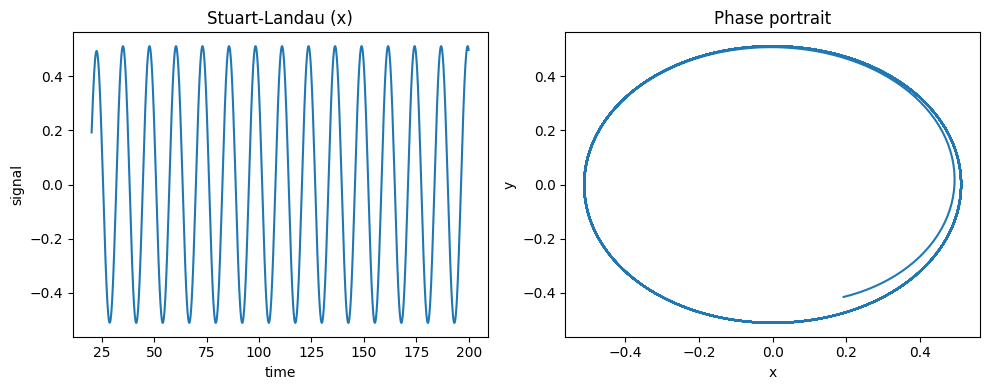

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
brainmass.viz.plot_timeseries(res['x'], ts=res['ts'], ax=axes[0])
axes[0].set_title('Stuart-Landau (x)')
brainmass.viz.plot_phase_portrait(res['x'], res['y'], ax=axes[1])
axes[1].set_title('Phase portrait')
plt.tight_layout()
plt.show()

## Try it: vary the intrinsic frequency `w`

The amplitude is fixed by `a`, but `w` sets how fast the node cycles. Higher `w` packs more periods into the same window.

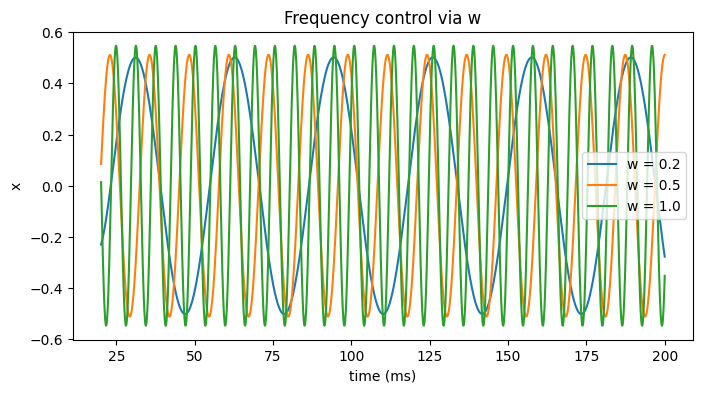

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for w in [0.2, 0.5, 1.0]:
    m = brainmass.StuartLandauStep(in_size=1, a=0.25, w=w)
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(
        200. * u.ms, monitors=['x'], transient=20. * u.ms)
    ax.plot(u.get_magnitude(r['ts']), u.get_magnitude(r['x'])[:, 0], label=f'w = {w}')
ax.set_xlabel('time (ms)'); ax.set_ylabel('x'); ax.legend()
ax.set_title('Frequency control via w')
plt.show()